In [3]:
import polars as pl
from pathlib import Path

In [4]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_ROOT = PROJECT_ROOT / "tennis_data"
data_path = DATA_ROOT / "Data"

In [5]:
# Load Point-by-Point data

pbp = pl.read_parquet(data_path / "point_by_point_clean.parquet")

print("Shape:", pbp.shape)
print("Columns:")
print(pbp.columns)

Shape: (2549369, 18)
Columns:
['match_id', 'set_id', 'game_id', 'point_id', 'home_point', 'away_point', 'point_description', 'home_point_type', 'away_point_type', 'home_score', 'away_score', 'serving', 'scoring', 'snapshot_date', 'sequence_issue', 'snapshot_issue', 'tiebreak_issue', 'standard_game_issue']


In [6]:
# Check values of serving and scoring columns

print("Serving values:")
print(pbp["serving"].value_counts())

print("\nScoring values:")
print(pbp["scoring"].value_counts())

Serving values:
shape: (2, 2)
┌─────────┬─────────┐
│ serving ┆ count   │
│ ---     ┆ ---     │
│ i64     ┆ u32     │
╞═════════╪═════════╡
│ 1       ┆ 1272024 │
│ 2       ┆ 1277345 │
└─────────┴─────────┘

Scoring values:
shape: (2, 2)
┌─────────┬─────────┐
│ scoring ┆ count   │
│ ---     ┆ ---     │
│ i64     ┆ u32     │
╞═════════╪═════════╡
│ 1       ┆ 1287765 │
│ 2       ┆ 1261604 │
└─────────┴─────────┘


In [7]:
# Inspect points from one sample game

sample_game = (
    pbp
    .select([
        "match_id",
        "set_id",
        "game_id",
        "point_id",
        "serving",
        "scoring",
        "home_score",
        "away_score",
        "point_description"
    ])
    .filter(
        (pl.col("match_id") == pbp["match_id"][0]) &
        (pl.col("set_id") == pbp["set_id"][0]) &
        (pl.col("game_id") == pbp["game_id"][0])
    )
)

sample_game

match_id,set_id,game_id,point_id,serving,scoring,home_score,away_score,point_description
i64,i64,i64,i64,i64,i64,i64,i64,i64
11998445,1,1,0,2,2,0,1,0
11998445,1,1,1,2,2,0,1,0
11998445,1,1,2,2,2,0,1,0
11998445,1,1,0,2,2,0,1,0
11998445,1,1,1,2,2,0,1,0
11998445,1,1,2,2,2,0,1,0


In [8]:
# Check snapshots for the sample game

sample_snapshots = (
    pbp
    .filter(
        (pl.col("match_id") == pbp["match_id"][0]) &
        (pl.col("set_id") == pbp["set_id"][0]) &
        (pl.col("game_id") == pbp["game_id"][0])
    )
    .select([
        "match_id",
        "set_id",
        "game_id",
        "point_id",
        "serving",
        "scoring",
        "snapshot_date"
    ])
    .sort(["snapshot_date", "point_id"])
)

sample_snapshots

match_id,set_id,game_id,point_id,serving,scoring,snapshot_date
i64,i64,i64,i64,i64,i64,date
11998445,1,1,0,2,2,2024-02-01
11998445,1,1,1,2,2,2024-02-01
11998445,1,1,2,2,2,2024-02-01
11998445,1,1,0,2,2,2024-02-02
11998445,1,1,1,2,2,2024-02-02
11998445,1,1,2,2,2,2024-02-02


In [9]:
# Keep only the latest snapshot for each point

pbp_latest = (
    pbp
    .sort("snapshot_date")
    .unique(
        subset=["match_id", "set_id", "game_id", "point_id"],
        keep="last"
    )
)

print("Original rows:", pbp.height)
print("Rows after removing old snapshots:", pbp_latest.height)

Original rows: 2549369
Rows after removing old snapshots: 1254740


In [10]:
# Check the last point of each game

game_last_points = (
    pbp_latest
    .sort(["match_id", "set_id", "game_id", "point_id"])
    .group_by(["match_id", "set_id", "game_id"])
    .last()
    .select([
        "match_id",
        "set_id",
        "game_id",
        "point_id",
        "serving",
        "scoring",
        "home_score",
        "away_score"
    ])
)

print("Number of games:", game_last_points.height)

game_last_points.head(10)

Number of games: 228225


match_id,set_id,game_id,point_id,serving,scoring,home_score,away_score
i64,i64,i64,i64,i64,i64,i64,i64
12027673,1,1,4,2,2,0,1
12105398,2,5,4,1,2,2,3
12071921,1,9,3,2,2,5,4
12166882,2,2,4,1,1,2,0
12025057,2,4,3,1,1,2,2
12049691,2,6,3,1,2,2,4
12106331,2,10,6,1,1,6,4
12189710,1,7,4,2,2,3,4
12194646,1,6,3,2,1,2,4


In [11]:
# Determine whether the server won each game

game_results = game_last_points.with_columns(
    (pl.col("serving") == pl.col("scoring"))
    .alias("server_won")
)

game_results.select([
    "match_id",
    "set_id",
    "game_id",
    "serving",
    "scoring",
    "server_won"
]).head(10)

match_id,set_id,game_id,serving,scoring,server_won
i64,i64,i64,i64,i64,bool
12027673,1,1,2,2,true
12105398,2,5,1,2,false
12071921,1,9,2,2,true
12166882,2,2,1,1,true
12025057,2,4,1,1,true
12049691,2,6,1,2,false
12106331,2,10,1,1,true
12189710,1,7,2,2,true
12194646,1,6,2,1,false


In [12]:
# Calculate percentage of service games won by the server

total_games = game_results.height
service_games_won = game_results.filter(
    pl.col("server_won") == True
).height

service_games_won_percentage = (
    service_games_won / total_games
) * 100

print("Total games:", total_games)
print("Service games won:", service_games_won)
print(
    "Percentage of service games won:",
    round(service_games_won_percentage, 2),
    "%"
)

Total games: 228225
Service games won: 153467
Percentage of service games won: 67.24 %


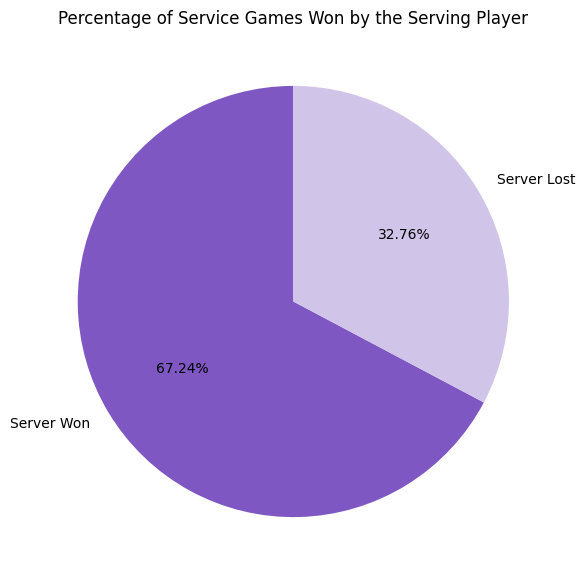

In [13]:
# Visualize the result

import matplotlib.pyplot as plt

won = service_games_won_percentage
lost = 100 - won

plt.figure(figsize=(7, 7))

plt.pie(
    [won, lost],
    labels=["Server Won", "Server Lost"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#7E57C2", "#D1C4E9"]
)

plt.title("Percentage of Service Games Won by the Serving Player")

plt.show()